In [1]:
import os
import ssl
import urllib.request

# DINOv2 weights download over HTTPS; relax SSL verification (macOS-friendly)
_ctx = ssl.create_default_context()
_ctx.check_hostname = False
_ctx.verify_mode = ssl.CERT_NONE
ssl._create_default_https_context = lambda *a, **k: _ctx
urllib.request.install_opener(
    urllib.request.build_opener(urllib.request.HTTPSHandler(context=_ctx))
)

import numpy as np
import torch
import torch.nn.functional as F
%matplotlib inline
import matplotlib.pyplot as plt

# Brain-DNN RSA with DINOv2 (self-supervised ViT)

Question: do early representations (edges/low-level) match early visual ROIs
(V1/V2), and deeper/semantic representations match higher ROIs (V4/LatOcc)?

We compare, via RSA, three kinds of model representation against each human
ROI's representation of the 120 test images:
  * raw_pixels   - trivial low-level baseline
  * gabor_edges  - canonical V1-like EDGE model (anchors the low-level end)
  * dino_block_k - patch features from DINOv2 ViT blocks at increasing depth
                   (early blocks = local/texture, late blocks = semantic)

DINOv2 is a strong semantic model with large receptive fields, so its earliest
blocks are still less "edge-like" than V1 (that's why we keep the Gabor edge
model as the low-level anchor. Together they span the hierarchy).

NOTE: with only 120 noisy fMRI test images, RDM correlations of ~0.05-0.2 are
the expected ceiling; the informative signal is the GRADIENT across blocks/ROIs.

In [2]:
with np.load(os.path.join("data", "kay_images.npz")) as dobj:
    dat = dict(**dobj)

stimuli_test = dat["stimuli_test"].astype(np.float32)  # (120,128,128)
responses_test = dat["responses_test"].astype(np.float32)
roi = dat["roi"]
roi_names = list(dat["roi_names"])
roi_ids = list(np.unique(roi))
H = stimuli_test.shape[1]
n_img = len(stimuli_test)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"device: {device} | test images: {n_img}")

device: mps | test images: 120


## Load DINOv2 (ViT-S/14) from torch.hub and extract per-block features

In [3]:
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dino = dino.to(device).eval()
for p in dino.parameters():
    p.requires_grad_(False)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
DINO_SIZE = 224  # multiple of patch size 14


def preprocess(images):
    """(n,H,W) grayscale -> (n,3,224,224) ImageNet-normalized tensor."""
    x = torch.from_numpy(images)[:, None]            # (n,1,H,W)
    lo, hi = x.min(), x.max()
    x = (x - lo) / (hi - lo + 1e-8)
    x = x.repeat(1, 3, 1, 1)                          # grayscale -> 3 channels
    x = F.interpolate(x, size=(DINO_SIZE, DINO_SIZE),
                      mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN) / IMAGENET_STD


# sample DINOv2 blocks from shallow to deep
BLOCK_IDS = [2, 5, 8, 11]


@torch.no_grad()
def dino_block_features(images, batch=16):
    """Mean-pooled patch tokens for each sampled block -> {name: (n, dim)}."""
    feats = {f"dino_b{b}": [] for b in BLOCK_IDS}
    for i in range(0, len(images), batch):
        x = preprocess(images[i:i + batch]).to(device)
        # returns a tuple of patch-token tensors (n_tokens, dim) per requested block
        outs = dino.get_intermediate_layers(x, n=BLOCK_IDS, reshape=False)
        for b, o in zip(BLOCK_IDS, outs):
            feats[f"dino_b{b}"].append(o.mean(dim=1).cpu().numpy())  # pool tokens
    return {k: np.concatenate(v, 0) for k, v in feats.items()}


print("extracting DINOv2 block features...")
dino_feats = dino_block_features(stimuli_test)
for k, v in dino_feats.items():
    print(f"{k}: {v.shape}")

Using cache found in /Users/mihailor/.cache/torch/hub/facebookresearch_dinov2_main
/Users/mihailor/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/mihailor/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/mihailor/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


extracting DINOv2 block features...
dino_b2: (120, 384)
dino_b5: (120, 384)
dino_b8: (120, 384)
dino_b11: (120, 384)


## Low-level anchor models: raw pixels + Gabor edge energy

In [4]:
def gabor_edge_features(imgs):
    orients = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    scales = [(0.06, 8, 8), (0.12, 5, 12), (0.24, 3, 16)]  # (freq, sigma, grid)
    Ff = np.fft.rfft2(imgs, axes=(1, 2))
    parts = []
    rr = np.arange(H) - H // 2
    xx, yy = np.meshgrid(rr, rr)
    for freq, sigma, grid in scales:
        step = H // grid
        env = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
        for th in orients:
            xr = xx * np.cos(th) + yy * np.sin(th)
            even = env * np.cos(2 * np.pi * freq * xr)
            odd = env * np.sin(2 * np.pi * freq * xr)
            ke = np.fft.rfft2(np.fft.ifftshift(even - even.mean()))
            ko = np.fft.rfft2(np.fft.ifftshift(odd - odd.mean()))
            re = np.fft.irfft2(Ff * ke, s=(H, H), axes=(1, 2))
            ro = np.fft.irfft2(Ff * ko, s=(H, H), axes=(1, 2))
            en = np.sqrt(re ** 2 + ro ** 2)[:, :grid * step, :grid * step]
            parts.append(en.reshape(len(imgs), grid, step, grid, step)
                         .mean(axis=(2, 4)).reshape(len(imgs), -1))
    return np.log1p(np.concatenate(parts, axis=1))


all_feats = {
    "raw_pixels": stimuli_test.reshape(n_img, -1),
    "gabor_edges": gabor_edge_features(stimuli_test),
    **dino_feats,
}

## RDMs and RSA (Spearman correlation of RDMs)

In [5]:
def rdm(mat):
    m = mat - mat.mean(1, keepdims=True)
    norm = np.linalg.norm(m, axis=1, keepdims=True) + 1e-8
    c = (m / norm) @ (m / norm).T
    iu = np.triu_indices(c.shape[0], k=1)
    return (1.0 - c)[iu]


def spearman(a, b):
    ra = np.argsort(np.argsort(a))
    rb = np.argsort(np.argsort(b))
    return float(np.corrcoef(ra, rb)[0, 1])


model_rdms = {k: rdm(v) for k, v in all_feats.items()}
models = ["raw_pixels", "gabor_edges"] + [f"dino_b{b}" for b in BLOCK_IDS]
rois = [str(roi_names[rid]) for rid in roi_ids]

## ROI RDMs: all voxels vs. only the most reliable voxels
Noisy voxels flatten the RDM and depress RSA. We also build ROI RDMs from the
TOP fraction of voxels by response variance across images (a reliability proxy: a voxel that varies meaningfully across stimuli carries signal, a flat voxel
is noise). This sharpens the brain representation and raises the ceiling.

In [6]:
TOP_FRACTION = 0.10  # keep the top 10% most-responsive voxels per ROI


def roi_rdm_set(top_fraction=None):
    out = {}
    for rid in roi_ids:
        resp = responses_test[:, roi == rid]
        if top_fraction is not None:
            var = resp.var(axis=0)
            k = max(1, int(top_fraction * resp.shape[1]))
            keep = np.argsort(var)[::-1][:k]
            resp = resp[:, keep]
        out[str(roi_names[rid])] = rdm(resp)
    return out


roi_rdms = roi_rdm_set(None)                       # all voxels
roi_rdms_top = roi_rdm_set(TOP_FRACTION)           # top-10% reliable voxels


def rsa_matrix(roi_rdm_dict):
    return np.array([[spearman(model_rdms[m], roi_rdm_dict[r]) for r in rois]
                     for m in models])


M = rsa_matrix(roi_rdms)
M_top = rsa_matrix(roi_rdms_top)

print("\nRSA (ALL voxels): model x ROI")
print("             " + "  ".join(f"{r:>7s}" for r in rois))
for mi, m in enumerate(models):
    print(f"{m:>12s}:  " + "  ".join(f"{M[mi, j]:7.3f}" for j in range(len(rois))))

print(f"\nRSA (TOP {int(TOP_FRACTION*100)}% voxels): model x ROI")
print("             " + "  ".join(f"{r:>7s}" for r in rois))
for mi, m in enumerate(models):
    print(f"{m:>12s}:  " + "  ".join(f"{M_top[mi, j]:7.3f}" for j in range(len(rois))))


RSA (ALL voxels): model x ROI
                  V1       V2       V3      V3A      V3B       V4   LatOcc
  raw_pixels:    0.042    0.025    0.013    0.001    0.003   -0.003   -0.000
 gabor_edges:    0.079    0.063    0.022    0.039    0.029   -0.061   -0.053
     dino_b2:    0.113    0.085    0.029   -0.007    0.014    0.005   -0.012
     dino_b5:    0.116    0.095    0.050    0.010    0.048    0.028   -0.000
     dino_b8:    0.079    0.074    0.062    0.039    0.102    0.050    0.011
    dino_b11:    0.049    0.059    0.079    0.037    0.112    0.095    0.070

RSA (TOP 10% voxels): model x ROI
                  V1       V2       V3      V3A      V3B       V4   LatOcc
  raw_pixels:    0.049    0.034    0.018    0.006    0.030   -0.004    0.002
 gabor_edges:    0.124    0.128    0.109    0.076    0.010    0.021    0.011
     dino_b2:    0.035    0.032    0.043    0.014    0.027    0.051    0.046
     dino_b5:    0.047    0.044    0.054    0.038    0.042    0.070    0.059
     dino_b8: 

In [7]:
print("\nBest-matching ROI for each model/block:")
for mi, m in enumerate(models):
    j = int(np.argmax(M[mi]))
    print(f"  {m:>12s} -> {rois[j]:8s} (r = {M[mi, j]:.3f})")

print("\nBest-matching model/block for each ROI (top-voxel RSA):")
for j, r in enumerate(rois):
    i = int(np.argmax(M_top[:, j]))
    print(f"  {r:>8s} -> {models[i]:12s} (r = {M_top[i, j]:.3f})")


Best-matching ROI for each model/block:
    raw_pixels -> V1       (r = 0.042)
   gabor_edges -> V1       (r = 0.079)
       dino_b2 -> V1       (r = 0.113)
       dino_b5 -> V1       (r = 0.116)
       dino_b8 -> V3B      (r = 0.102)
      dino_b11 -> V3B      (r = 0.112)

Best-matching model/block for each ROI (top-voxel RSA):
        V1 -> gabor_edges  (r = 0.124)
        V2 -> gabor_edges  (r = 0.128)
        V3 -> gabor_edges  (r = 0.109)
       V3A -> dino_b8      (r = 0.088)
       V3B -> dino_b11     (r = 0.105)
        V4 -> dino_b11     (r = 0.097)
    LatOcc -> dino_b11     (r = 0.111)


## Permutation significance test
For each (model, ROI) cell we shuffle the image order of one RDM many times and
recompute the RSA, building a null distribution. The p-value is the fraction of
shuffles whose |r| meets or exceeds the observed |r| (two-sided).

In [8]:
def squareform(condensed, n):
    D = np.zeros((n, n))
    iu = np.triu_indices(n, k=1)
    D[iu] = condensed
    return D + D.T


N_PERM = 2000
perm_rng = np.random.default_rng(0)


def perm_pvalues(roi_rdm_dict, observed):
    P = np.ones_like(observed)
    for j, r in enumerate(rois):
        print(f'Cell: {j} {r}')
        Dr = squareform(roi_rdm_dict[r], n_img)
        for mi, m in enumerate(models):
            obs = abs(observed[mi, j])
            count = 0
            for _ in range(N_PERM):
                p = perm_rng.permutation(n_img)
                shuf = Dr[np.ix_(p, p)][np.triu_indices(n_img, k=1)]
                if abs(spearman(model_rdms[m], shuf)) >= obs:
                    count += 1
            P[mi, j] = (count + 1) / (N_PERM + 1)
    return P


print(f"\nrunning permutation test ({N_PERM} shuffles per cell)...")
Pvals = perm_pvalues(roi_rdms_top, M_top)


running permutation test (2000 shuffles per cell)...
Cell: 0 V1
Cell: 1 V2
Cell: 2 V3
Cell: 3 V3A
Cell: 4 V3B
Cell: 5 V4
Cell: 6 LatOcc


## Multiple-comparison correction (Benjamini-Hochberg FDR)
We test 42 cells, so ~2 would be "significant" by chance at p<0.05. BH-FDR
controls the expected false-discovery rate across all cells; `Sig` marks the
cells that survive correction.

In [9]:
def bh_fdr(pvals, q=0.05):
    """Benjamini-Hochberg: return boolean mask of rejections at FDR level q."""
    flat = pvals.ravel()
    order = np.argsort(flat)
    ranked = flat[order]
    n = len(flat)
    thresh = q * (np.arange(1, n + 1) / n)
    passed = ranked <= thresh
    if not passed.any():
        return np.zeros_like(flat, dtype=bool).reshape(pvals.shape)
    kmax = np.max(np.where(passed))           # largest rank meeting BH threshold
    crit_p = ranked[kmax]
    return (pvals <= crit_p)


FDR_Q = 0.05
Sig = bh_fdr(Pvals, q=FDR_Q)
n_raw = int((Pvals < 0.05).sum())
n_fdr = int(Sig.sum())
print(f"\nsignificant cells: {n_raw} at raw p<0.05, "
      f"{n_fdr} survive BH-FDR (q={FDR_Q})")

print(f"\nTop-{int(TOP_FRACTION*100)}% RSA  (* = raw p<0.05, "
      f"† = survives BH-FDR q={FDR_Q}):")
print("             " + "  ".join(f"{r:>8s}" for r in rois))
for mi, m in enumerate(models):
    cells = []
    for j in range(len(rois)):
        mark = "†" if Sig[mi, j] else ("*" if Pvals[mi, j] < 0.05 else " ")
        cells.append(f"{M_top[mi, j]:6.3f}{mark}")
    print(f"{m:>12s}:  " + "  ".join(cells))


significant cells: 31 at raw p<0.05, 31 survive BH-FDR (q=0.05)

Top-10% RSA  (* = raw p<0.05, † = survives BH-FDR q=0.05):
                   V1        V2        V3       V3A       V3B        V4    LatOcc
  raw_pixels:   0.049†   0.034†   0.018    0.006    0.030†  -0.004    0.002 
 gabor_edges:   0.124†   0.128†   0.109†   0.076†   0.010    0.021    0.011 
     dino_b2:   0.035†   0.032    0.043†   0.014    0.027    0.051†   0.046†
     dino_b5:   0.047†   0.044†   0.054†   0.038    0.042†   0.070†   0.059†
     dino_b8:   0.064†   0.056†   0.072†   0.088†   0.072†   0.083†   0.086†
    dino_b11:   0.052†   0.041†   0.071†   0.066†   0.105†   0.097†   0.111†


## Visualization

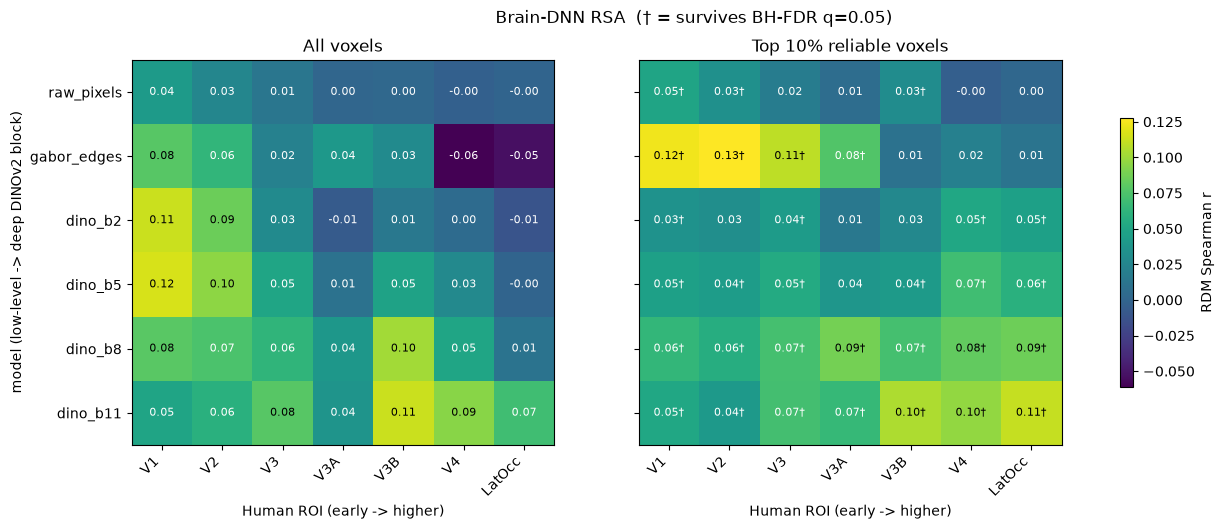

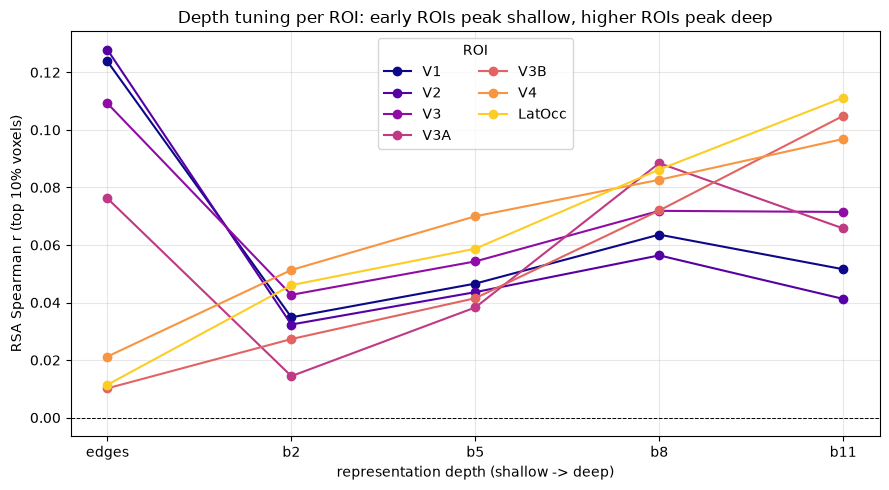

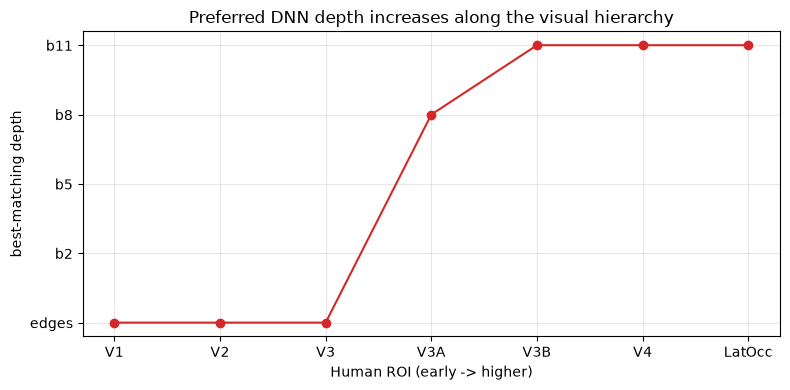


saved figs/rsa_dino_roi.png, figs/rsa_depth_gradient.png, figs/rsa_peak_depth.png


In [14]:
### Chart 1: full vs top-10% heatmaps, side by side (dagger = FDR sig)
vmax = max(M.max(), M_top.max())
vmin = min(M.min(), M_top.min())
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, mat, title, sig in [
    (axs[0], M, "All voxels", None),
    (axs[1], M_top, f"Top {int(TOP_FRACTION*100)}% reliable voxels", Sig),
]:
    im = ax.imshow(mat, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(rois)))
    ax.set_xticklabels(rois, rotation=45, ha="right")
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models)
    ax.set(xlabel="Human ROI (early -> higher)", title=title)
    for i in range(len(models)):
        for j in range(len(rois)):
            mark = "†" if (sig is not None and sig[i, j]) else ""
            ax.text(j, i, f"{mat[i, j]:.2f}{mark}", ha="center", va="center",
                    color="white" if mat[i, j] < vmax * 0.6 else "black",
                    fontsize=8)
axs[0].set_ylabel("model (low-level -> deep DINOv2 block)")
fig.suptitle(f"Brain-DNN RSA  († = survives BH-FDR q={FDR_Q})")
fig.colorbar(im, ax=axs, shrink=.7, label="RDM Spearman r")
fig.savefig("figs/rsa_dino_roi.png", dpi=120)
plt.show()

### Chart 2: depth gradient - RSA vs DNN depth, one line per ROI
# Makes the early-layer<->early-ROI correspondence explicit: early ROIs should
# peak at shallow depth, higher ROIs at deep blocks.
depth_models = ["gabor_edges"] + [f"dino_b{b}" for b in BLOCK_IDS]
depth_idx = [models.index(m) for m in depth_models]
x = np.arange(len(depth_models))
# order ROIs along the visual hierarchy for a clean colour ramp
hier = ["V1", "V2", "V3", "V3A", "V3B", "V4", "LatOcc"]
hier = [r for r in hier if r in rois]
colors = plt.cm.plasma(np.linspace(0, 0.9, len(hier)))

fig2, ax2 = plt.subplots(figsize=(9, 5))
for r, c in zip(hier, colors):
    j = rois.index(r)
    ax2.plot(x, M_top[depth_idx, j], "o-", color=c, label=r)
ax2.axhline(0, color="k", lw=.7, ls="--")
ax2.set_xticks(x)
ax2.set_xticklabels(["edges"] + [f"b{b}" for b in BLOCK_IDS])
ax2.set(xlabel="representation depth (shallow -> deep)",
        ylabel=f"RSA Spearman r (top {int(TOP_FRACTION*100)}% voxels)",
        title="Depth tuning per ROI: early ROIs peak shallow, higher ROIs peak deep")
ax2.legend(title="ROI", ncol=2)
ax2.grid(alpha=.3)
fig2.tight_layout()
fig2.savefig("figs/rsa_depth_gradient.png", dpi=120)
plt.show()

### Chart 3: peak depth per ROI - one-number summary of the gradient
peak_depth = [float(np.argmax(M_top[depth_idx, rois.index(r)])) for r in hier]
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(range(len(hier)), peak_depth, "o-", color="tab:red")
ax3.set_xticks(range(len(hier)))
ax3.set_xticklabels(hier)
ax3.set_yticks(range(len(depth_models)))
ax3.set_yticklabels(["edges"] + [f"b{b}" for b in BLOCK_IDS])
ax3.set(xlabel="Human ROI (early -> higher)",
        ylabel="best-matching depth",
        title="Preferred DNN depth increases along the visual hierarchy")
ax3.grid(alpha=.3)
fig3.tight_layout()
fig3.savefig("figs/rsa_peak_depth.png", dpi=120)
plt.show()

print("\nsaved figs/rsa_dino_roi.png, figs/rsa_depth_gradient.png, figs/rsa_peak_depth.png")